</div>
<div class="alert alert-block alert-primary">

# <p align="center">📚 Assignment</p>
# <p align="center">🧪 Iterative Weighted Least Squares</p>

</div>


<p>
  <img src="https://upload.wikimedia.org/wikipedia/commons/0/04/ChatGPT_logo.svg" alt="ChatGPT Icon" width="28" style="vertical-align:middle; margin-right: 8px;">
  <strong>Use of GenAI: Required Declaration</strong>
</p>

> In this assessment, you **can use** generative AI tools to develop and deepen your understanding of your code — for example:
> - "Explain how this works to me"
> - "Help me find the bug in this code"
>
> You **may not use** GenAI to directly generate programs or solutions for submission.
>
> ---
>
> Any use of generative AI must be **explicitly acknowledged** by:
> - Stating the **prompts or questions** you used
> - Describing **how the output was used**
>
> In your report, you should discuss how you used the output from GenAI. This declaration is **mandatory** and ensures transparency in accordance with Monash University's academic integrity guidelines.
>
> ---
>
> ⚠️ **Important:** Failure to disclose permitted use — or using GenAI for prohibited tasks — may be treated as a breach of academic integrity.

## ⚠️ Before You Begin

This notebook contains the starter code and comments you need to complete this part of the assignment. Feel free to add your own Markdown cells to include additional explanations, notes, or reflections.

Please follow the inline comments and Markdown instructions carefully.

- 🔒 **Do not modify any code blocks explicitly marked as "Do not change."**
- 🧠 **Use your own Markdown/Python cells if needed.**
- ✅ **Make sure to run all cells and generate outputs before submission.**

Cells marked `### YOUR CODE HERE` are the ones you must complete. They currently raise
`NotImplementedError` so that an unfinished notebook fails loudly rather than silently.

Good luck with the assignment!

In [19]:
## Libraries. Include more if you need them.
import os
import numpy as np                ## Numpy is the fundamental building block for tensors (matrices) in Python
import matplotlib.pyplot as plt   ## Matplotlib.pyplot is the graphing library we use throughout the semester

## Setting seeds for reproducibility. Do NOT change these!
RND_SEED = 42
np.random.seed(RND_SEED)

<b>Enter your student details below</b>

- <b>Student Name:</b> Shang Chen
- <b>Student ID:</b> 30586267

In [20]:
student_name = "Shang Chen"        ## Replace with your name;       e.g., student_name = "Mehrtash Harandi"
student_id   = "30586267"   ## Replace with your student ID; e.g., student_id = "123456789" 

### 🧩 Iterative Weighted Least Squares

In some problems, not every data point is equally reliable. Attaching a weight to each sample gives us a
principled way to model this. Consider a dataset in which each point $(\boldsymbol{x}_i, y_i)$, with
$\boldsymbol{x}_i \in \mathbb{R}^n$ and $y_i \in \mathbb{R}$, carries a weighting factor
$0 < \alpha_i \le 1$. The weighted sum-of-squares loss of a model with parameters
$\boldsymbol{w} \in \mathbb{R}^n$ is

$$ \mathcal{L}_{\mathrm{wSE}}(\boldsymbol{w}) = \frac{1}{m}\sum_{i=1}^{m}\alpha_i\,(\boldsymbol{w}^\top \boldsymbol{x}_i - y_i)^2 $$

and it can be shown that its minimiser is available in closed form:

$$ \boldsymbol{w}^\ast = (\boldsymbol{X}^\top \boldsymbol{A} \boldsymbol{X})^{-1}\boldsymbol{X}^\top \boldsymbol{A} \boldsymbol{y} $$

Here $\boldsymbol{X}$ is $m \times n$ with row $i$ equal to $\boldsymbol{x}_i^\top$, $\boldsymbol{y}$ is the
$m$-dimensional vector stacking the $y_i$, and $\boldsymbol{A}$ is the $m \times m$ diagonal matrix with
$\boldsymbol{A}[i,i] = \alpha_i$.

The purpose of this task is to train a regression model that **learns how much to trust each sample while it is
being fitted**. Since the reliability of a sample is unknown, we infer it from the residuals and iterate,
updating $\boldsymbol{A}$ with

$$ \hat{\alpha}_i = \exp\!\big(-\sigma\,(y_i^{\text{noisy}} - \hat{y}_i)^2\big) $$

where $\sigma > 0$ is a hyperparameter you tune.

---

> ### ⚠️ "Linear" here means linear **in the parameters**
>
> The data you are given is one-dimensional, and the underlying relationship is **not** a straight line. A
> straight-line fit will do badly no matter how you weight the samples — that is not what this exercise is
> testing.
>
> Both equations above hold for *any* feature map $\boldsymbol{\phi} : \mathbb{R} \to \mathbb{R}^n$: replace
> $\boldsymbol{x}_i$ with $\boldsymbol{\phi}(x_i)$ and let row $i$ of $\boldsymbol{X}$ be
> $\boldsymbol{\phi}(x_i)^\top$. The model $\hat{y} = \boldsymbol{w}^\top \boldsymbol{\phi}(x)$ is still linear in
> $\boldsymbol{w}$, so the closed form is unchanged. You are expected to choose a suitable
> $\boldsymbol{\phi}$ — a **polynomial basis** $\boldsymbol{\phi}(x) = (1, x, x^2, \ldots, x^{d})^\top$ is the
> natural starting point — and to justify the degree $d$ you settle on.

---

#### What you are given
`data/iwls_data.npz`, containing four arrays:

| array | size | description |
|---|---|---|
| `x_trn`, `y_trn` | 250 | training samples. Labels are **corrupted**: every label carries Gaussian measurement noise, and roughly 10% are additionally hit by a large outlier. |
| `x_val`, `y_val` | 150 | validation samples with **clean** labels. |

You are *not* told which training samples are the outliers — recovering that information is the point of the
$\alpha_i$.

#### Your tasks
1. **Baseline (3 marks).** Fit an unweighted least-squares model with your chosen feature map. Report the
   validation MSE and plot the fit against the training and validation data. Comment on how the outliers
   distort it.
2. **IWLS (4 marks).** Implement the iterative scheme. Report the validation MSE, plot the IWLS fit alongside
   the baseline, and show how the training error, validation error, and sample weights evolve over iterations.
3. **Analysis (3 marks).** Report the validation MSE as a function of $\sigma$ and explain the shape of the
   curve — in particular what goes wrong at both extremes. Then inspect the learned $\alpha_i$: which training
   samples end up down-weighted, and does that agree with what you see in the scatter plot?

#### Two hints that save a lot of pain
- **Rescale $x$ to roughly $[-1,1]$ *before* raising it to powers.** Otherwise $\boldsymbol{X}^\top\boldsymbol{X}$
  becomes badly conditioned and your fitted coefficients are numerical noise.
- **Select $d$ and $\sigma$ on the *validation* error.** The training error will **increase** as the iterations
  proceed — you are deliberately ignoring some training points — so it is not a model-selection signal.

---

loaded data/iwls_data.npz  |  train: 250 samples   val: 150 samples


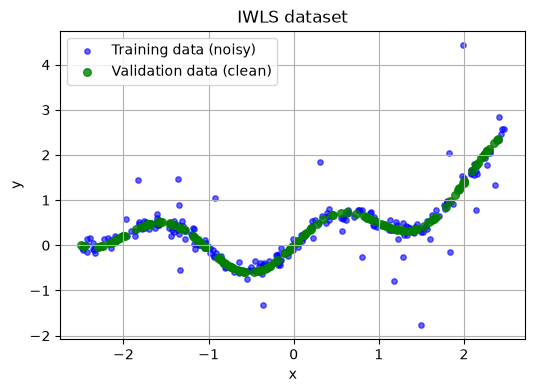

In [21]:
# Do not change this cell
_path = "data/iwls_data.npz" if os.path.exists("data/iwls_data.npz") else "iwls_data.npz"
data  = np.load(_path)
x_trn = data["x_trn"]
y_trn = data["y_trn"]
x_val = data["x_val"]
y_val = data["y_val"]
print(f"loaded {_path}  |  train: {x_trn.shape[0]} samples   val: {x_val.shape[0]} samples")

plt.figure(figsize=(6,4))
plt.scatter(x_trn, y_trn, s=15, color='blue',  label='Training data (noisy)', alpha=0.6)
plt.scatter(x_val, y_val, s=30, color='green', label='Validation data (clean)', alpha=0.8)
plt.xlabel('x'); plt.ylabel('y'); plt.title('IWLS dataset')
plt.legend(); plt.grid(); plt.show()

---
## Part 1 — Baseline: ordinary least squares  

Build your feature map and fit an **unweighted** model, i.e. $\boldsymbol{A} = \boldsymbol{I}$.

You may use `sklearn` (`PolynomialFeatures`, `LinearRegression`) or implement the closed form yourself with
`numpy`.

In [22]:
### YOUR CODE HERE
from sklearn.preprocessing import (
    PolynomialFeatures,
    MinMaxScaler,
)

poly = PolynomialFeatures(9, include_bias=True)
X_new_trn = poly.fit_transform(x_trn.reshape(-1,1), y_trn)

A = np.identity(X_new_trn.shape[0])

normaliser = MinMaxScaler(feature_range=(-1, 1)) 
normaliser.fit(X_new_trn)
X_new_trn_norm = normaliser.transform(X_new_trn)

w_trn = np.linalg.inv(X_new_trn_norm.T @ A @ X_new_trn_norm) @ X_new_trn_norm.T @ A @ y_trn

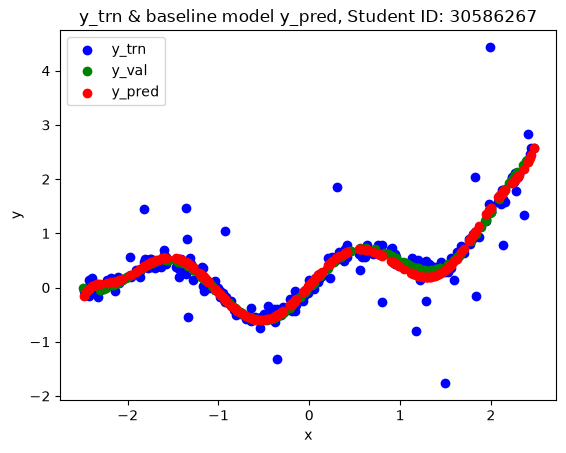

In [ ]:
figure1, ax = plt.subplots()
ax.scatter(x_trn, y_trn, c='b', label="y_trn")
ax.scatter(x_val, y_val, c='g', label="y_val")
ax.scatter(x_trn, X_new_trn_norm@w_trn, c='r', label="y_pred")
plt.title("y_trn & baseline model y_pred, Student ID: 30586267")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
# plt.savefig("plot1.png", dpi=300)
plt.show()

---
## Part 2 — IRLS

Implement and run IRLS method. You must not use any library that implements IRLS for you. You may use `sklearn` or `numpy` to implement the closed form solution for weighted least squares.

In [24]:
def weighted_ls(X, y, alpha=None):
    """Closed-form weighted least squares.

    Solves  w = (X^T A X)^{-1} X^T A y,  with A = diag(alpha).

    Args:
        X     : (m, n) feature matrix.
        y     : (m,)   targets.
        alpha : (m,)   sample weights, or None for the unweighted solution.

    Returns:
        w of shape (n,).
    """
    ### YOUR CODE HERE
    if alpha is not None:
        A = np.diag(alpha)
    else:
        A = np.identity(X.shape[0])
        
    w = np.linalg.inv(X.T @ A @ X) @ X.T @ A @ y

    return w

In [36]:
def iwls(X_trn, y_trn, X_val, y_val, sigma=10.0, max_iter=40, degree=1, verbose=True):
    """Iterative weighted least squares.

    Each iteration: fit w with the current alpha, record the errors, then reweight from the
    training residuals. Return the iterate with the lowest validation MSE.

    Returns:
        best    : dict with keys 'val_mse', 'w', 'iter', 'alpha'.
        history : dict of per-iteration lists — at minimum 'train_mse', 'val_mse',
                  'alpha_mean', 'alpha_min' — so you can plot convergence in Part 3.
    """
    ### YOUR CODE HERE
    history = {
        'train_mse': np.zeros(max_iter),
        'val_mse': np.zeros(max_iter),
        'alpha_mean': np.zeros(max_iter),
        'alpha_min': np.zeros(max_iter),
    }

    best = {
        'val_mse': None,
        'w': None,
        'iter': None,
        'alpha': None,
    }
    
    poly = PolynomialFeatures(degree, include_bias=True)
    poly.fit(X_trn.reshape(-1,1))
    X_trn_new = poly.transform(X_trn.reshape(-1,1))
    X_val_new = poly.transform(X_val.reshape(-1,1))

    normaliser = MinMaxScaler(feature_range=(-1, 1)) 
    normaliser.fit(X_trn_new)
    X_trn_new_norm = normaliser.transform(X_trn_new)
    X_val_new_norm = normaliser.transform(X_val_new)
    
    w = weighted_ls(X_trn_new_norm, y_trn, alpha=None)

    alpha = np.ones(X_trn.shape[0])
    
    for i in range(max_iter):
        y_trn_pred = X_trn_new_norm@w
        y_val_pred = X_val_new_norm@w
        
        history['train_mse'][i] = np.mean((y_trn-y_trn_pred)**2)
        history['val_mse'][i] = np.mean((y_val-y_val_pred)**2)
        history['alpha_mean'][i] = np.mean(alpha)
        history['alpha_min'][i] = np.min(alpha)

        if best['val_mse'] is None or best['val_mse'] > history['val_mse'][i]:
            best['val_mse'] = history['val_mse'][i]
            best['w'] = w
            best['iter'] = i
            best['alpha'] = alpha

        if verbose:
            print(f"iter: {i}")
            print(f"train_mse: {history['train_mse'][i]}")
            print(f"val_mse: {history['val_mse'][i]}")

        alpha = np.exp(-sigma*(y_trn-y_trn_pred)**2)
        w = weighted_ls(X_trn_new_norm, y_trn, alpha=alpha)

    return best, history, X_trn_new_norm, alpha
        
        

In [ ]:
# Run IWLS with a sigma of your choice and report the best validation MSE.
### YOUR CODE HERE
best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=55, max_iter=40, degree=9, verbose=True)

iter: 0
train_mse: 0.1209212446251193
val_mse: 0.004277185261129884
iter: 1
train_mse: 0.12165292275627294
val_mse: 0.0015431502678069982
iter: 2
train_mse: 0.12254299492032868
val_mse: 0.0008113745542159843
iter: 3
train_mse: 0.12317948675869832
val_mse: 0.0005797532402650926
iter: 4
train_mse: 0.12360783349286643
val_mse: 0.0004959350911541216
iter: 5
train_mse: 0.12389463675781633
val_mse: 0.00046199492941520834
iter: 6
train_mse: 0.12408792529327066
val_mse: 0.00044653873937915514
iter: 7
train_mse: 0.12421951610736456
val_mse: 0.000438501443115637
iter: 8
train_mse: 0.12431014447392982
val_mse: 0.0004337132334317989
iter: 9
train_mse: 0.12437332104187238
val_mse: 0.00043051073400351655
iter: 10
train_mse: 0.12441789865160578
val_mse: 0.0004281876929374669
iter: 11
train_mse: 0.12444972724214706
val_mse: 0.00042641852946359284
iter: 12
train_mse: 0.12447271137223734
val_mse: 0.0004250356978316631
iter: 13
train_mse: 0.12448948584755695
val_mse: 0.00042394115427130797
iter: 14
train

In [27]:
print(best['iter'])
print(best['val_mse'])

39
0.0004196998501118245


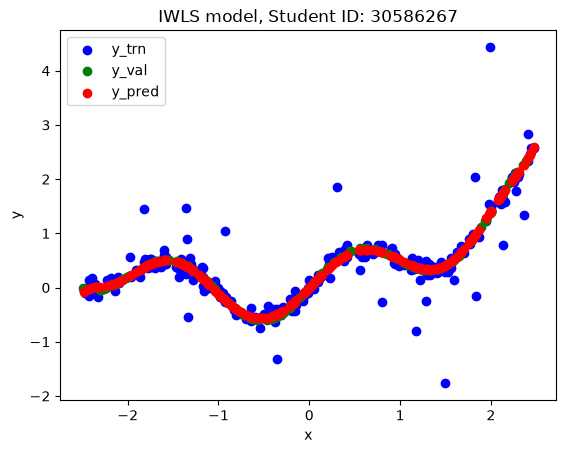

In [28]:
figure1, ax = plt.subplots()
ax.scatter(x_trn, y_trn, c='b', label="y_trn")
ax.scatter(x_val, y_val, c='g', label="y_val")
ax.scatter(x_trn, X_trn_new_norm@best['w'], c='r', label="y_pred")
plt.title("IWLS model, Student ID: 30586267")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
# plt.savefig("plot2.png", dpi=300)
plt.show()

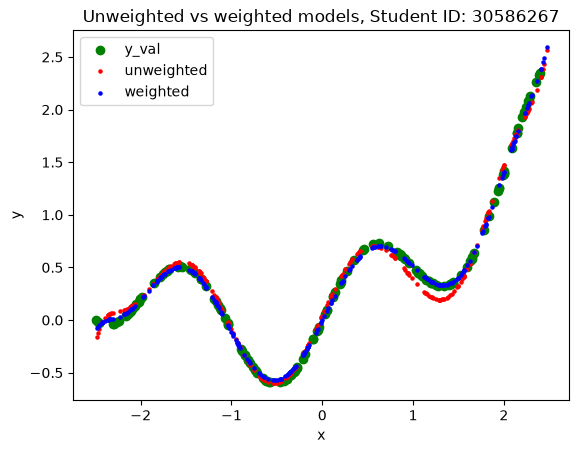

In [29]:
figure1, ax = plt.subplots()
ax.scatter(x_val, y_val, c='g', label="y_val")
ax.scatter(x_trn, X_trn_new_norm@w_trn, c='r', s=5, label="unweighted")
ax.scatter(x_trn, X_trn_new_norm@best['w'], c='b', s=5, label="weighted")
plt.title("Unweighted vs weighted models, Student ID: 30586267")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
# plt.savefig("plot3.png", dpi=300)
plt.show()

---
## Part 3 — Analysis  

Three things to show here: the effect of $\sigma$, the convergence behaviour, and what the learned $\alpha_i$
actually pick out.

In [ ]:
### YOUR CODE HERE
optimal = {
    'val_mse': None,
    'degree': None,
}

for i in range(1, 30):
    best, history, X_trn_new_norm alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=10, max_iter=1, degree=i, verbose=False)
    # print(f"degree: {i}")
    # print(f"val_mse: {history['val_mse'][0]}")

    if optimal['val_mse'] is None or optimal['val_mse'] > history['val_mse'][0]:
        optimal['val_mse'] = history['val_mse'][0]
        optimal['degree'] = i

print(f"best degree: {optimal['degree']}")
print(f"val_mse: {optimal['val_mse']}")

best degree: 9
val_mse: 0.004277185261129884


In [ ]:
optimal = {
    'val_mse': None,
    'sigma': None,
}

sigma_max = 100

optimisation_history = {
    'val_mse': np.zeros(sigma_max),
}

for i in range(sigma_max):
    best, history, X_trn_new_norm, alpha= iwls(x_trn, y_trn, x_val, y_val, sigma=i, max_iter=40, degree=9, verbose=False)
    # print(f"sigma: {i}")
    # print(f"val_mse: {history['val_mse'][0]}")
    optimisation_history['val_mse'][i] = best['val_mse']

    if optimal['val_mse'] is None or optimal['val_mse'] > best['val_mse']:
        optimal['val_mse'] = best['val_mse']
        optimal['sigma'] = i

print(f"best sigma: {optimal['sigma']}")
print(f"val_mse: {optimal['val_mse']}")

best sigma: 55
val_mse: 0.0004196998501118245


In [ ]:
best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=55, max_iter=40, degree=9, verbose=False)

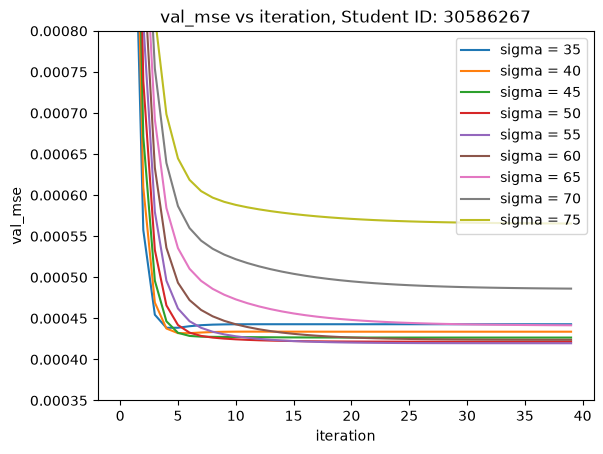

In [ ]:
x = range(40)
figure1, ax = plt.subplots()

for i in range(35, 80, 5):
    best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=i, max_iter=40, degree=9, verbose=False)
    ax.plot(x, history['val_mse'][x], label=f'sigma = {i}')

plt.title("val_mse vs iteration, Student ID: 30586267")
plt.xlabel("iteration")
plt.ylabel("val_mse")
plt.ylim(0.00035, 0.0008)
plt.legend()
plt.savefig("plot4.png", dpi=300)
plt.show()

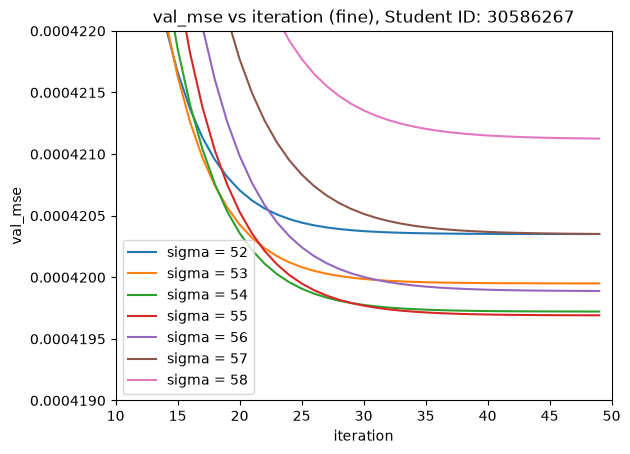

In [ ]:
x = range(50)
figure1, ax = plt.subplots()

for i in range(52, 59):
    best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=i, max_iter=50, degree=9, verbose=False)
    ax.plot(x, history['val_mse'][x], label=f'sigma = {i}')

plt.title("val_mse vs iteration (fine), Student ID: 30586267")
plt.xlabel("iteration")
plt.ylabel("val_mse")
plt.xlim(10, 50)
plt.ylim(0.000419, 0.000422)
plt.legend()
plt.savefig("plot5.png", dpi=300)
plt.show()

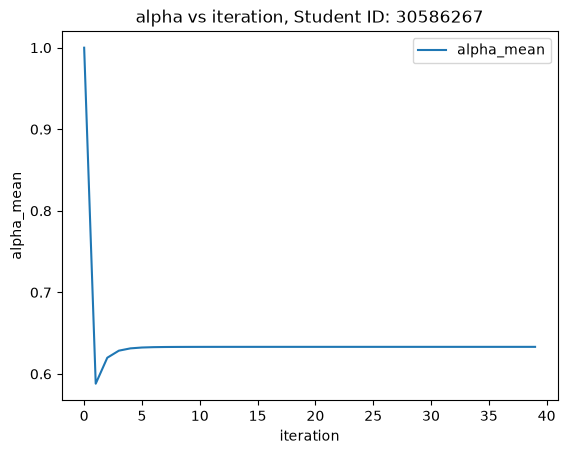

In [ ]:
x = range(40)

best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=55, max_iter=40, degree=9, verbose=False)

figure1, ax = plt.subplots()
ax.plot(x, history['alpha_mean'][x], label='alpha_mean')
# ax.plot(x, history['alpha_min'][x], label='alpha_min')

plt.title("alpha vs iteration, Student ID: 30586267")
plt.xlabel("iteration")
plt.ylabel("alpha_mean")
plt.legend()
# plt.savefig("plot6.png", dpi=300)
plt.show()

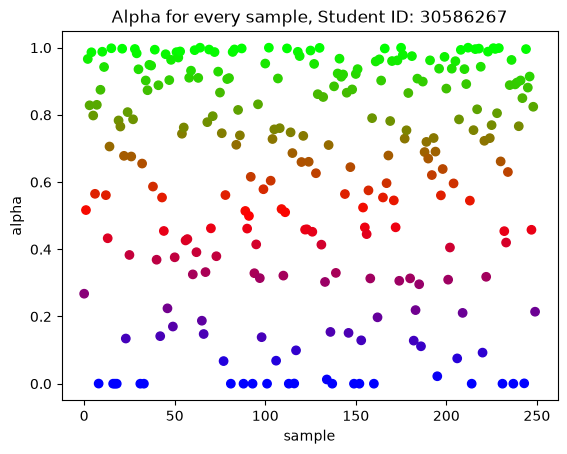

In [59]:
best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=55, max_iter=40, degree=9, verbose=False)

figure1, ax = plt.subplots()
ax.scatter(np.arange(best['alpha'].size), best['alpha'], c=best['alpha'], cmap="brg")
# ax.plot(x, history['alpha_min'][x], label='alpha_min')

plt.title("Alpha for every sample, Student ID: 30586267")
plt.xlabel("sample")
plt.ylabel("alpha")
# plt.legend()
plt.savefig("q2/Alpha_per_sample.png", dpi=300)
plt.show()

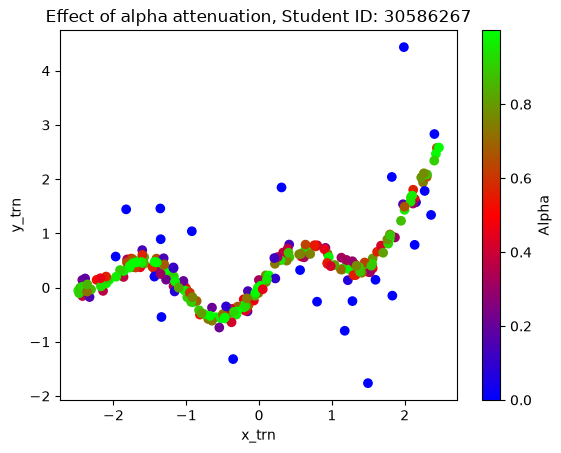

In [58]:
figure1, ax = plt.subplots()
plot = ax.scatter(x_trn, y_trn, c=best['alpha'], cmap="brg", label="y_trn")
# ax.scatter(x_val, y_val, c='g', label="y_val")
# ax.scatter(x_trn, X_trn_new_norm@best['w'], c='r', label="y_pred")
plt.title("Effect of alpha attenuation, Student ID: 30586267")
ax.figure.colorbar(plot, ax=ax, label="Alpha")
plt.xlabel("x_trn")
plt.ylabel("y_trn")
# plt.legend()
plt.savefig("q2/atten_target.png", dpi=300)
plt.show()

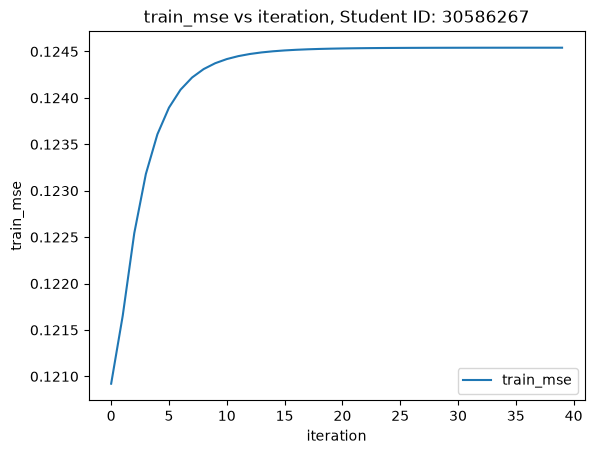

In [ ]:
x = range(40)

best, history, X_trn_new_norm, alpha = iwls(x_trn, y_trn, x_val, y_val, sigma=55, max_iter=40, degree=9, verbose=False)

figure1, ax = plt.subplots()
ax.plot(x, history['train_mse'][x], label='train_mse')

plt.title("train_mse vs iteration, Student ID: 30586267")
plt.xlabel("iteration")
plt.ylabel("train_mse")
plt.legend()
plt.savefig("plot7.png", dpi=300)
plt.show()

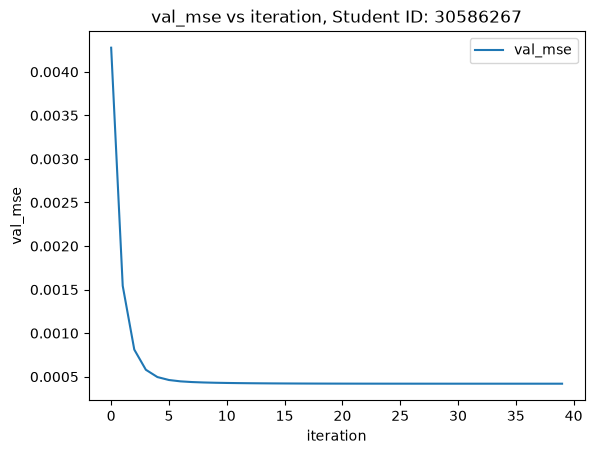

In [19]:
x = range(40)

best, history, X_trn_new_norm = iwls(x_trn, y_trn, x_val, y_val, sigma=55, max_iter=40, degree=9, verbose=False)

figure1, ax = plt.subplots()
ax.plot(x, history['val_mse'][x], label='val_mse')

plt.title("val_mse vs iteration, Student ID: 30586267")
plt.xlabel("iteration")
plt.ylabel("val_mse")
plt.legend()
plt.savefig("plot8.png", dpi=300)
plt.show()

In [20]:
print(history['train_mse'][-1])
print(history['val_mse'][-1])


0.12454046876928337
0.0004196998501118245


---
## ✅ Checklist before you submit

- [ ] Student name and ID filled in at the top.
- [ ] All cells run top to bottom without error, with outputs saved.
- [ ] Part 1: validation MSE reported, baseline fit plotted, distortion discussed.
- [ ] Part 2: IWLS implemented, validation MSE reported, both fits plotted together.
- [ ] Part 3: $\sigma$ sweep, convergence curves, and $\alpha_i$ analysis, each with a written comment.
- [ ] Chosen degree $d$ and $\sigma$ justified — on **validation** error, not training error.
- [ ] GenAI use declared as described at the top of this notebook.
- [ ] Figures and discussion copied into your PDF report; the report is what we mark.

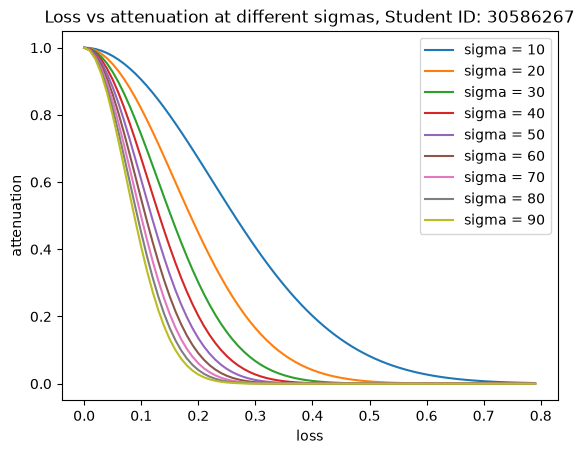

In [17]:
import numpy as np
import matplotlib.pyplot as plt

sigma_list = np.arange(10, 100, 10)

x = np.arange(0, 0.8, 0.01)

figure1, ax = plt.subplots()

for sigma in sigma_list:
    y = np.exp(-sigma*(x**2))
    ax.plot(x, y, label=f'sigma = {sigma}')

plt.title("Loss vs attenuation at different sigmas, Student ID: 30586267")
plt.xlabel("loss")
plt.ylabel("attenuation")
# plt.xlim(10, 50)
# plt.ylim(0.000419, 0.000422)
plt.legend()
plt.savefig("q2/attenuation_graph.png", dpi=300)
plt.show()